In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

Dataset Snapshot:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Data Info & Null Checks:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 

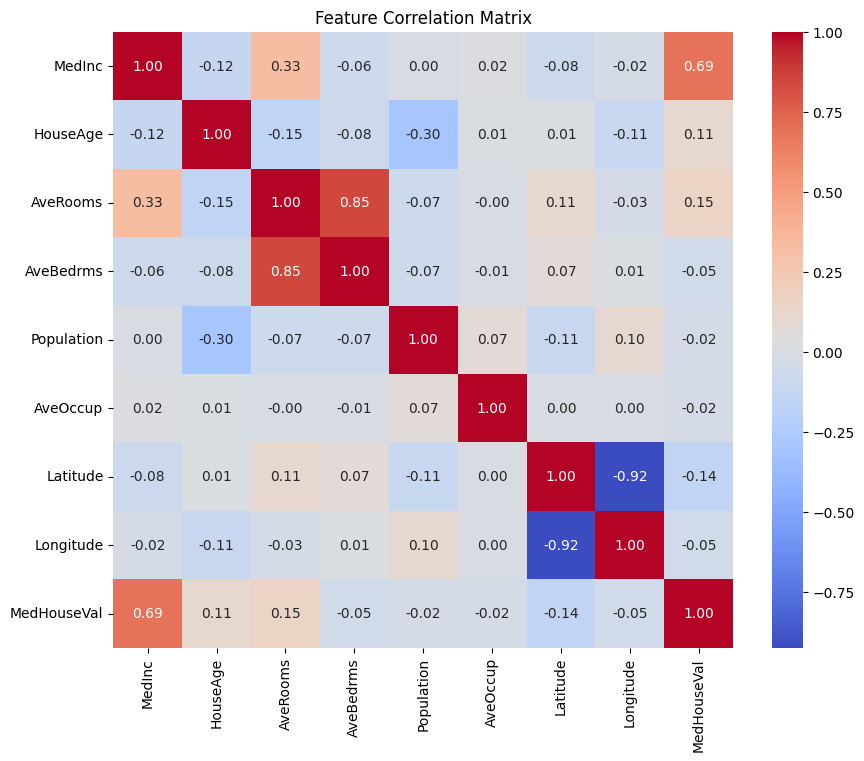


Model Performance Summary:
MAE: 0.533
RMSE: 0.746
R² Score: 0.576


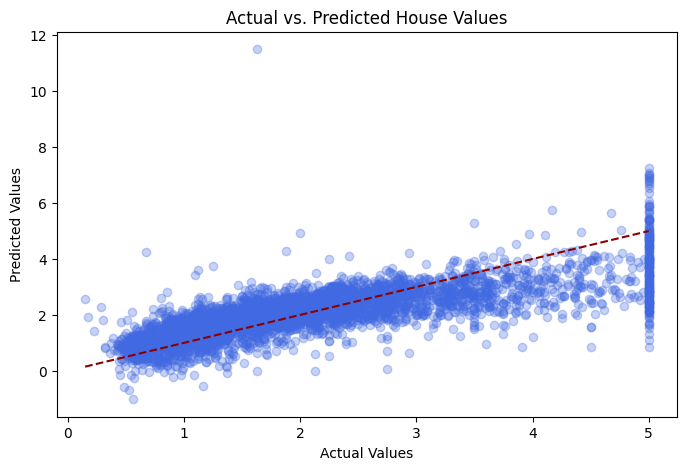

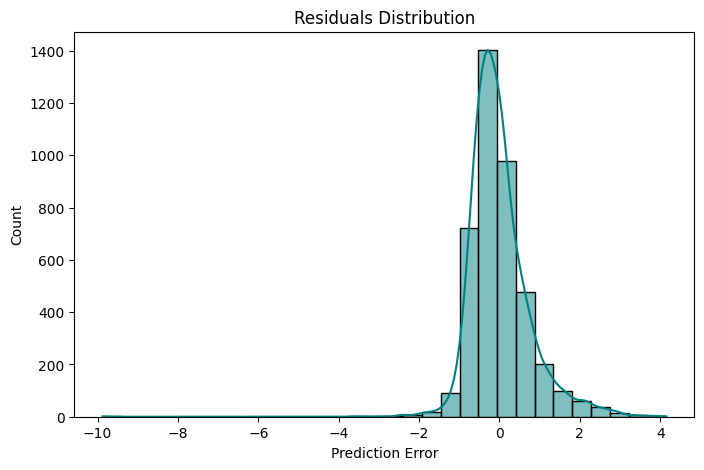


Model saved locally as 'california_housing_lr_model.pkl'


In [1]:
# Importing the essentials for data handling, plotting, and modeling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib 

# Grabbing the California housing data from sklearn
raw_data = fetch_california_housing(as_frame=True)
df = pd.concat([raw_data.data, raw_data.target.rename('MedHouseVal')], axis=1)

# Quick sanity check to see what the data actually looks like
print("Dataset Snapshot:")
print(df.head())

# Checking for missing values and general structure
print("\nData Info & Null Checks:")
df.info()
print(df.isnull().sum())  # Looks like we're good, no missing data to clean up

# Let's see how the features correlate with each other
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

# Setting up our features (X) and target variable (y)
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Splitting data: 80% for training, 20% to test how well the model generalizes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initializing and training the basic Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Running predictions on our test set
predictions = lr_model.predict(X_test)

# Calculating the baseline performance metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\nModel Performance Summary:")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# Visualizing predictions vs reality
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='darkred', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted House Values")
plt.show()

# Checking the distribution of our errors (residuals)
errors = y_test - predictions
plt.figure(figsize=(8, 5))
sns.histplot(errors, kde=True, bins=30, color='teal')
plt.xlabel("Prediction Error")
plt.title("Residuals Distribution")
plt.show()

# Saving the model to a file so we can reuse it later without retraining
joblib.dump(lr_model, 'california_housing_lr_model.pkl')
print("\nModel saved locally as 'california_housing_lr_model.pkl'")